In [1]:
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

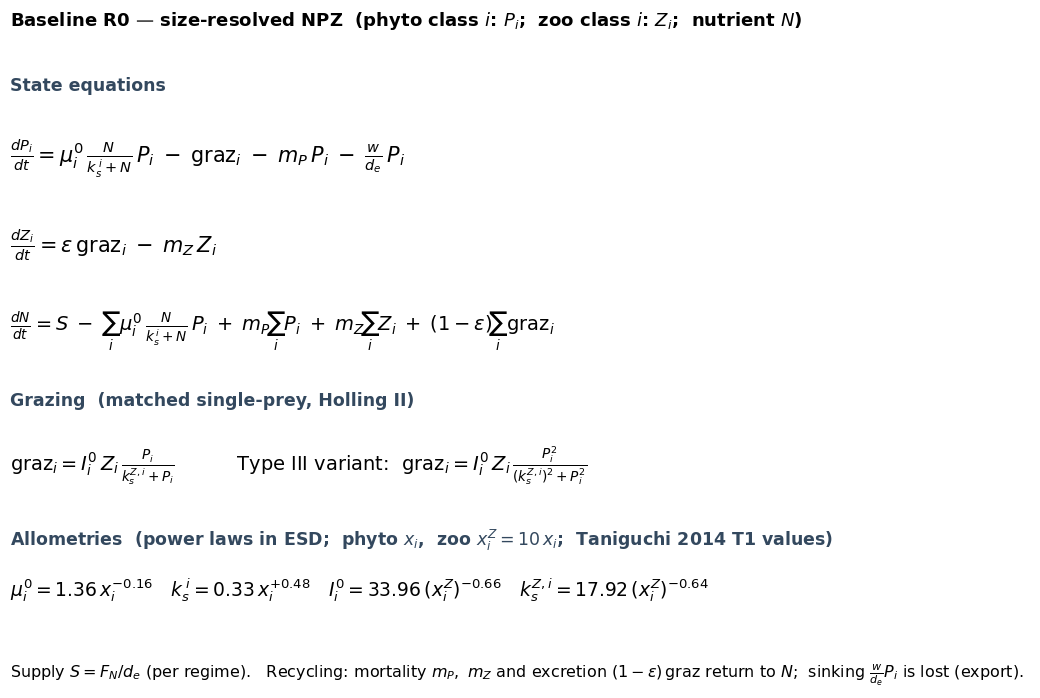

In [13]:
# ── Fig 0 — Model equations (R0 baseline, Banas-2011 notation) ────────────────
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 7.5)); fig.patch.set_facecolor('white')
def L(y, s, size=14, x=0.05, weight='normal', color='k'):
    fig.text(x, y, s, fontsize=size, weight=weight, color=color, va='top')

L(0.96, "Baseline R0 — size-resolved NPZ  (phyto class $i$: $P_i$;  zoo class $i$: $Z_i$;  nutrient $N$)",
  size=13, weight='bold')
L(0.87, "State equations", size=12.5, weight='bold', color='#33485e')
L(0.79, r"$\frac{dP_i}{dt}=\mu^0_i\,\frac{N}{k_s^{\,i}+N}\,P_i\;-\;\mathrm{graz}_i\;-\;m_P\,P_i\;-\;\frac{w}{d_e}\,P_i$", size=15)
L(0.67, r"$\frac{dZ_i}{dt}=\varepsilon\,\mathrm{graz}_i\;-\;m_Z\,Z_i$", size=15)
L(0.56, r"$\frac{dN}{dt}=S\;-\;\sum_i \mu^0_i\,\frac{N}{k_s^{\,i}+N}\,P_i\;+\;m_P\!\sum_i P_i\;+\;m_Z\!\sum_i Z_i\;+\;(1-\varepsilon)\!\sum_i \mathrm{graz}_i$", size=14)
L(0.45, "Grazing  (matched single-prey, Holling II)", size=12.5, weight='bold', color='#33485e')
L(0.38, r"$\mathrm{graz}_i=I^0_i\,Z_i\,\frac{P_i}{k_s^{Z,i}+P_i}$"
        r"          Type III variant:  $\mathrm{graz}_i=I^0_i\,Z_i\,\frac{P_i^{2}}{(k_s^{Z,i})^{2}+P_i^{2}}$", size=14)
L(0.27, "Allometries  (power laws in ESD;  phyto $x_i$,  zoo $x_i^{Z}=10\\,x_i$;  Taniguchi 2014 T1 values)",
  size=12.5, weight='bold', color='#33485e')
L(0.205, r"$\mu^0_i=1.36\,x_i^{-0.16}\quad k_s^{\,i}=0.33\,x_i^{+0.48}\quad"
         r"I^0_i=33.96\,(x_i^{Z})^{-0.66}\quad k_s^{Z,i}=17.92\,(x_i^{Z})^{-0.64}$", size=13.5)
L(0.09, r"Supply $S=F_N/d_e$ (per regime).   Recycling: mortality $m_P,\ m_Z$ and excretion "
        r"$(1-\varepsilon)\,\mathrm{graz}$ return to $N$;  sinking $\frac{w}{d_e}P_i$ is lost (export).", size=11.5)
plt.axis('off'); plt.show()

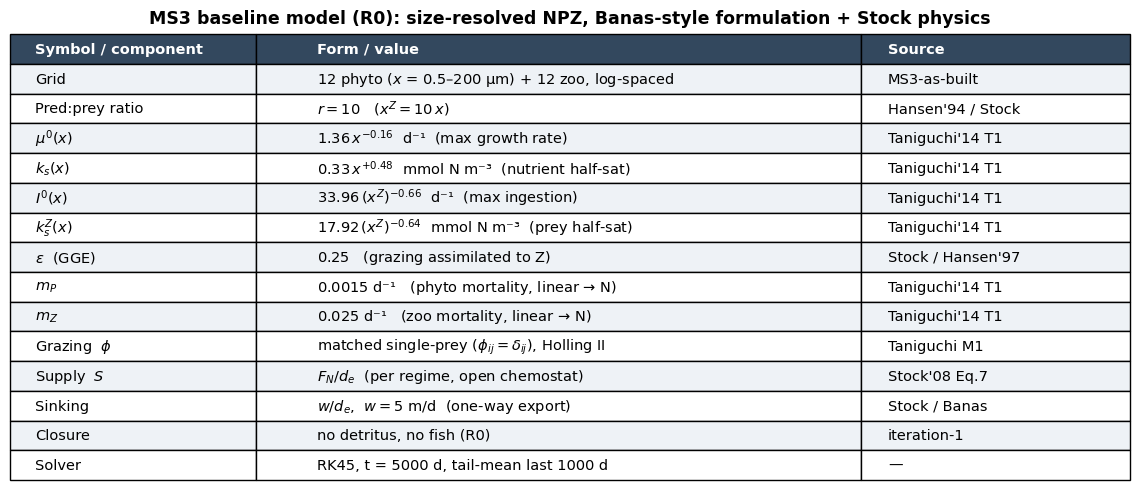

In [14]:
# ── Fig 1 — Model structure & parameters (mathtext / LaTeX-style) ─────────────
import matplotlib.pyplot as plt
rows = [
    ("Grid",                 r"12 phyto ($x$ = 0.5–200 µm) + 12 zoo, log-spaced", "MS3-as-built"),
    ("Pred:prey ratio",      r"$r = 10$   ($x^{Z} = 10\,x$)",                     "Hansen'94 / Stock"),
    (r"$\mu^0(x)$",          r"$1.36\,x^{-0.16}$  d⁻¹  (max growth rate)",        "Taniguchi'14 T1"),
    (r"$k_s(x)$",            r"$0.33\,x^{+0.48}$  mmol N m⁻³  (nutrient half-sat)","Taniguchi'14 T1"),
    (r"$I^0(x)$",            r"$33.96\,(x^{Z})^{-0.66}$  d⁻¹  (max ingestion)",   "Taniguchi'14 T1"),
    (r"$k_s^{Z}(x)$",        r"$17.92\,(x^{Z})^{-0.64}$  mmol N m⁻³  (prey half-sat)", "Taniguchi'14 T1"),
    (r"$\varepsilon$  (GGE)", r"$0.25$   (grazing assimilated to Z)",             "Stock / Hansen'97"),
    (r"$m_P$",               r"$0.0015$ d⁻¹   (phyto mortality, linear → N)",     "Taniguchi'14 T1"),
    (r"$m_Z$",               r"$0.025$ d⁻¹   (zoo mortality, linear → N)",        "Taniguchi'14 T1"),
    (r"Grazing  $\phi$",     r"matched single-prey ($\phi_{ij}=\delta_{ij}$), Holling II", "Taniguchi M1"),
    (r"Supply  $S$",         r"$F_N/d_e$  (per regime, open chemostat)",          "Stock'08 Eq.7"),
    ("Sinking",              r"$w/d_e$,  $w=5$ m/d  (one-way export)",            "Stock / Banas"),
    ("Closure",              "no detritus, no fish (R0)",                        "iteration-1"),
    ("Solver",               "RK45, t = 5000 d, tail-mean last 1000 d",          "—"),
]
fig, ax = plt.subplots(figsize=(11.5, 5)); ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=["Symbol / component", "Form / value", "Source"],
               cellLoc='left', colLoc='left', loc='center', colWidths=[0.22, 0.54, 0.24])
tbl.auto_set_font_size(False); tbl.set_fontsize(10.5); tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#33485e'); cell.set_text_props(color='w', weight='bold')
    elif r % 2: cell.set_facecolor('#eef2f6')
ax.set_title("MS3 baseline model (R0): size-resolved NPZ, Banas-style formulation + Stock physics",
             fontsize=12.5, weight='bold', pad=14)
plt.tight_layout(); plt.show()

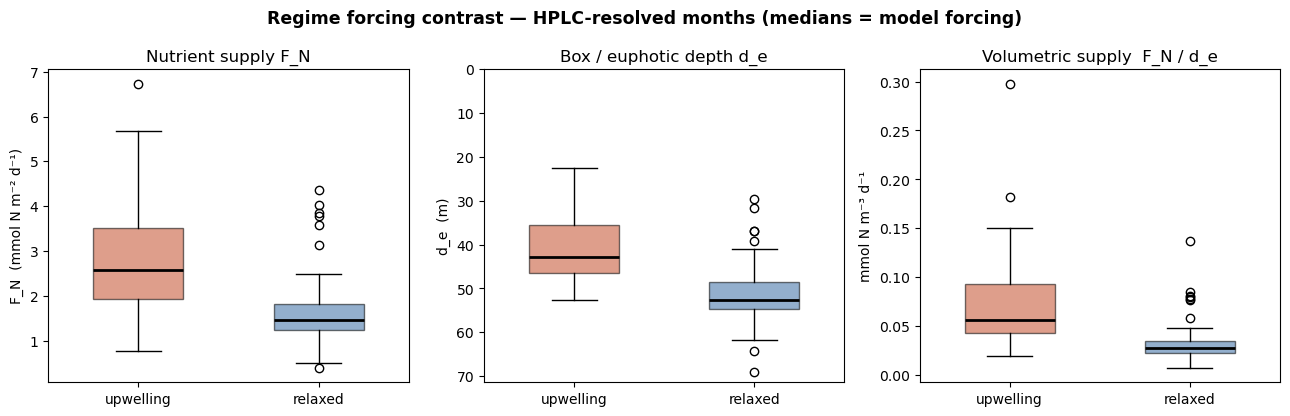

upwelling  n=31  F_N median=2.58  d_e median=42.8
relaxed    n=58  F_N median=1.45  d_e median=52.7


In [21]:
# ── Fig 2 — The forcing: upwelling vs relaxed split in the data (HPLC months) ──
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import cariaco_obs as co
df = pd.read_csv(co.DEFAULT_CSV_PATH)
rc = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
phyto_cols = ['pico_mmolN', 'nano_mmolN', 'micro_mmolN']
COL = {'upwelling': '#c44e2c', 'relaxed': '#3a6ea5'}
data = {r: df[df[rc] == r].dropna(subset=phyto_cols) for r in ('upwelling', 'relaxed')}

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
def regime_box(a, series, title, ylab):
    vals = [data[r][series].dropna().values for r in ('upwelling', 'relaxed')]
    bp = a.boxplot(vals, patch_artist=True, widths=0.5)          # no labels= kwarg
    for patch, r in zip(bp['boxes'], ('upwelling', 'relaxed')):
        patch.set_facecolor(COL[r]); patch.set_alpha(0.55)
    for med in bp['medians']:
        med.set_color('k'); med.set_linewidth(2)
    a.set(title=title, ylabel=ylab)
    a.set_xticks([1, 2]); a.set_xticklabels(['upwelling', 'relaxed'])
regime_box(ax[0], 'FN_mmolN_m2_d', 'Nutrient supply F_N', 'F_N  (mmol N m⁻² d⁻¹)')
regime_box(ax[1], 'depth_cutoff',  'Box / euphotic depth d_e', 'd_e  (m)')
ax[1].set_ylim(bottom=0); ax[1].invert_yaxis()   # surface (0) at top, depth downward
for r in ('upwelling', 'relaxed'):
    vsup = (data[r]['FN_mmolN_m2_d'] / data[r]['depth_cutoff']).dropna().values
    ax[2].boxplot([vsup], positions=[0 if r=='upwelling' else 1], patch_artist=True, widths=0.5,
                  boxprops=dict(facecolor=COL[r], alpha=0.55), medianprops=dict(color='k', lw=2))
ax[2].set(title='Volumetric supply  F_N / d_e', ylabel='mmol N m⁻³ d⁻¹',
          xticks=[0,1], xticklabels=['upwelling', 'relaxed'])
fig.suptitle('Regime forcing contrast — HPLC-resolved months (medians = model forcing)',
             fontsize=12.5, weight='bold')
plt.tight_layout(); plt.show()
for r in ('upwelling', 'relaxed'):
    print(f"{r:10s} n={len(data[r]):2d}  F_N median={data[r]['FN_mmolN_m2_d'].median():.2f}  "
          f"d_e median={data[r]['depth_cutoff'].median():.1f}")

In [25]:
# Cell A — forcings + wiring (Inflow__ -> Supply__), per-regime d_e and sinking
import numpy as np, matplotlib.pyplot as plt
import cariaco_obs as co
import run_baseline_diagnostic as rbd
from cariaco_baseline_setups import (
    model_baseline, model_setup_baseline, phyto_esd, zoo_esd, W_SINK)
from parscan_utils import compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS

phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']

def regime_forcing(regime):
    obs_vec, labels, bdefs, mdf, forcing = co.load_cariaco_targets(
        regime=regime, months='hplc', agg='median')
    fn, de = forcing['Inflow__FN'], forcing['Inflow__de']
    obs_phyto = np.array([obs_vec[labels.index(b['label'])] for b in phyto_bin_defs])
    obs_cent = compute_phyto_spectrum_metrics(obs_phyto, phyto_bin_defs)['centroid']
    return dict(regime=regime, FN=fn, de=de, w_over_de=W_SINK/de,
                obs_centroid=obs_cent, obs_mcs=10**obs_cent)

forc = {r: regime_forcing(r) for r in ('upwelling', 'relaxed')}
for r, f in forc.items():
    print(f"{r:10s}  F_N={f['FN']:.3f}  d_e={f['de']:.1f}  "
          f"w/d_e={f['w_over_de']:.3f}  obs mean-cell={f['obs_mcs']:.2f} µm")

upwelling   F_N=2.579  d_e=42.8  w/d_e=0.117  obs mean-cell=5.50 µm
relaxed     F_N=1.450  d_e=52.7  w/d_e=0.095  obs mean-cell=2.00 µm


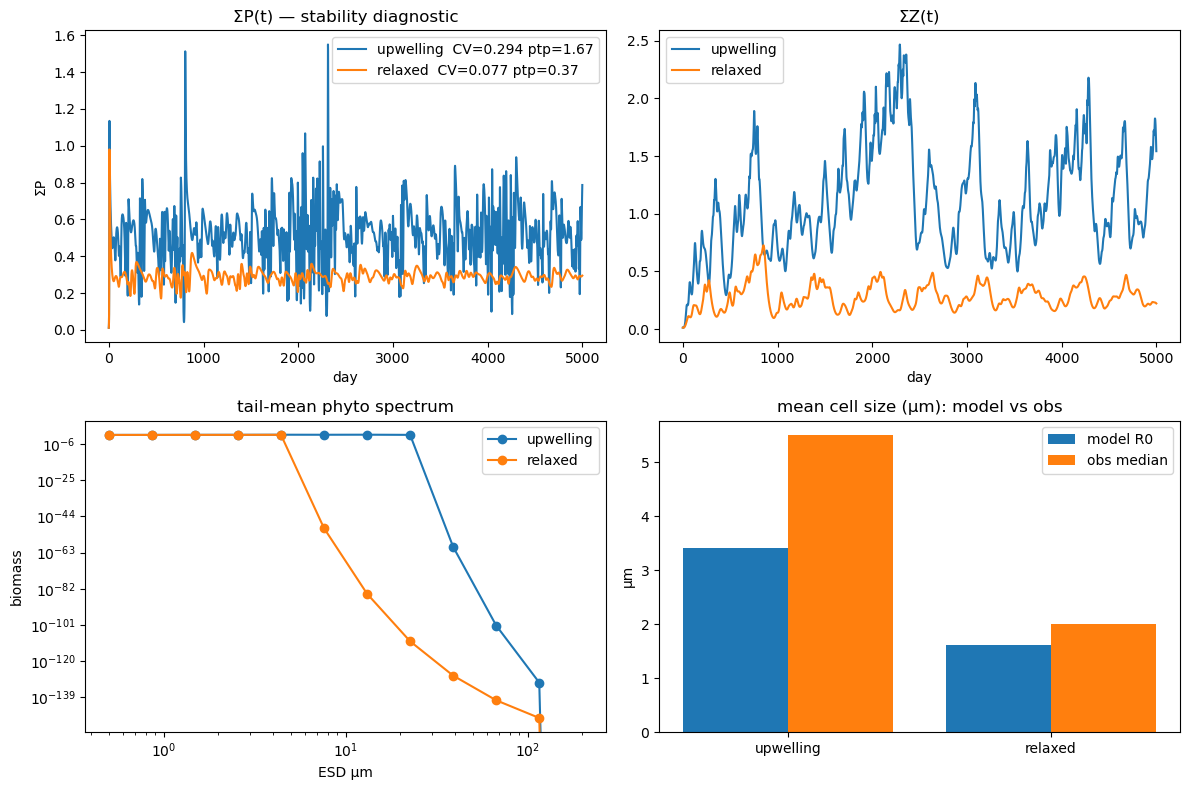

upwelling  model mean-cell=3.41 µm  obs=5.50 µm  NBSS=-1.103  CV(ΣP)=0.294
relaxed    model mean-cell=1.62 µm  obs=2.00 µm  NBSS=-19.150  CV(ΣP)=0.077


In [31]:
# Cell B — R0 (Type II, matched, no fish): run both regimes, stability + spectrum + mean cell size
TAIL = 1000
def run_regime(f):
    ov = {'Supply':      {'FN': float(f['FN']), 'de': float(f['de'])},
          'PhytoSinking': {'w_over_de': float(f['w_over_de'])}}
    out   = rbd.run_setup(model_baseline, model_setup_baseline, input_vars_override=ov)
    state = rbd.extract_state(out)
    m     = rbd.compute_metrics(state, phyto_esd, zoo_esd, tail_len=TAIL)
    sumP_t = state['P'].sum(axis=0)
    tail   = sumP_t[-TAIL:]
    cv     = tail.std() / max(tail.mean(), 1e-12)          # ~0 => settled, large => limit cycle
    ptp    = (tail.max() - tail.min()) / max(tail.mean(), 1e-12)
    return state, m, sumP_t, cv, ptp
res = {r: run_regime(f) for r, f in forc.items()}
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for r, (state, m, sumP_t, cv, ptp) in res.items():
    ax[0,0].plot(sumP_t, label=f"{r}  CV={cv:.3f} ptp={ptp:.2f}")
    ax[0,1].plot(state['Z'].sum(axis=0), label=r)
    ax[1,0].plot(phyto_esd, state['P'][:, -TAIL:].mean(axis=1), 'o-', label=r)
ax[0,0].set(title='ΣP(t) — stability diagnostic', xlabel='day', ylabel='ΣP')
ax[0,1].set(title='ΣZ(t)', xlabel='day'); ax[1,0].set(xscale='log', yscale='log',
            title='tail-mean phyto spectrum', xlabel='ESD µm', ylabel='biomass')
for a in (ax[0,0], ax[0,1], ax[1,0]): a.legend()
mcs = {r: 10**res[r][1]['centroid'] for r in forc}
xs = np.arange(2)
ax[1,1].bar(xs-0.2, [mcs[r] for r in forc], 0.4, label='model R0')
ax[1,1].bar(xs+0.2, [forc[r]['obs_mcs'] for r in forc], 0.4, label='obs median')
ax[1,1].set(xticks=xs, title='mean cell size (µm): model vs obs', ylabel='µm')
ax[1,1].set_xticklabels(list(forc)); ax[1,1].legend()
plt.tight_layout(); plt.show()
for r in forc:
    print(f"{r:10s} model mean-cell={mcs[r]:.2f} µm  obs={forc[r]['obs_mcs']:.2f} µm  "
          f"NBSS={res[r][1]['nbss_slope']:+.3f}  CV(ΣP)={res[r][3]:.3f}")

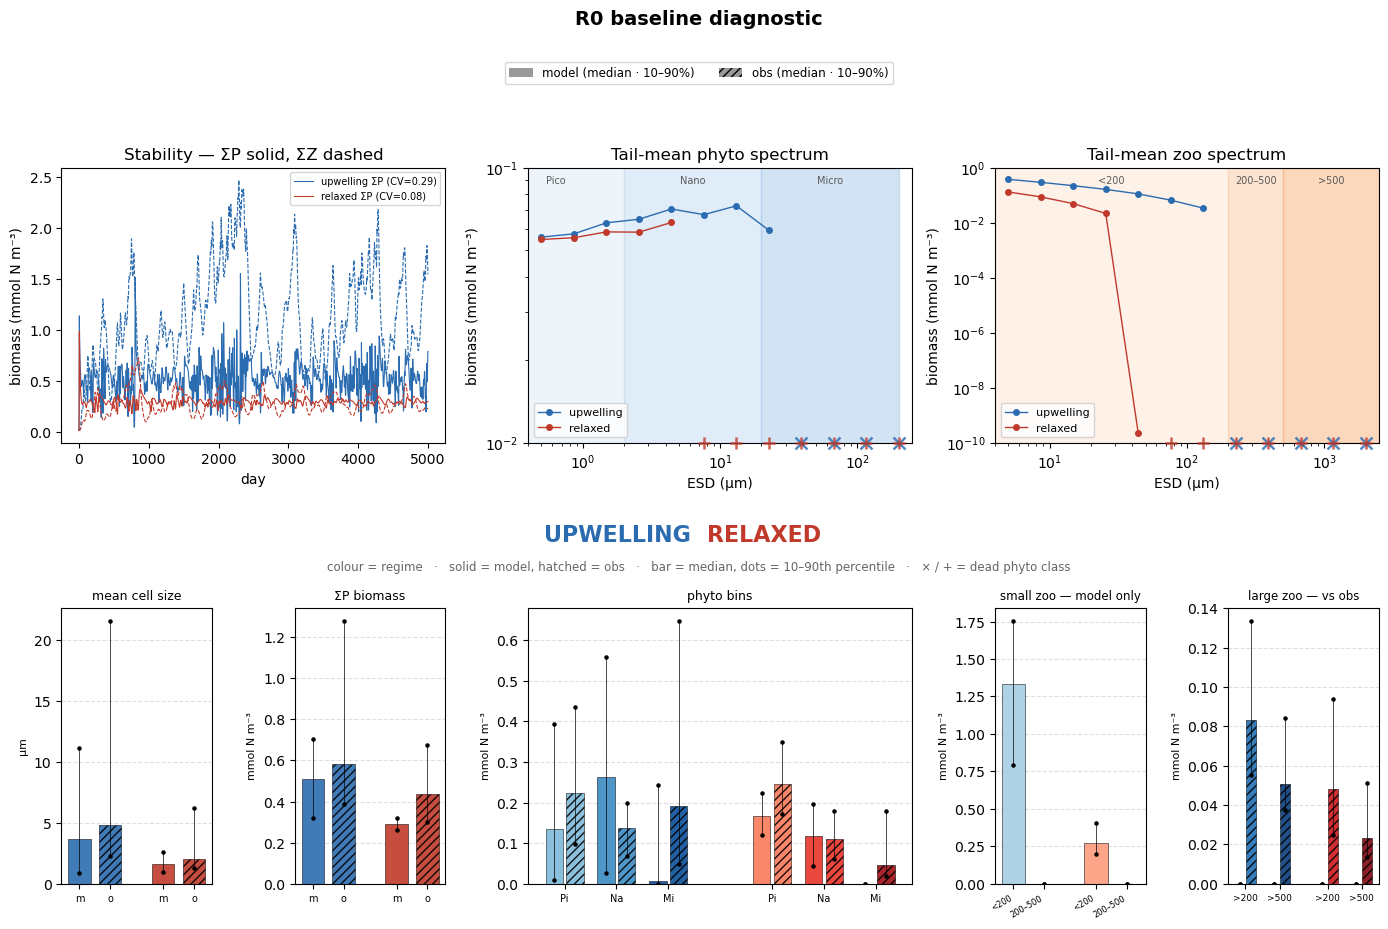

In [30]:
# ══ R0 DIAGNOSTIC v4 — final: same-floor dead markers, y-labels, whisker legend ══
import importlib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, NullFormatter
import cariaco_obs as co, run_baseline_diagnostic as rbd
import cariaco_baseline_setups as cbs; importlib.reload(cbs)

TAIL = 1000; DEAD = 1e-10; regimes = ['upwelling', 'relaxed']
REG_COL = {'upwelling': '#2b6cb0', 'relaxed': '#c0392b'}
DEAD_MK = {'upwelling': 'x', 'relaxed': '+'}
RAMP3 = {'upwelling': plt.cm.Blues([.45, .65, .88]), 'relaxed': plt.cm.Reds([.45, .65, .88])}
RAMP4 = {'upwelling': plt.cm.Blues([.35, .55, .75, .95]), 'relaxed': plt.cm.Reds([.35, .55, .75, .95])}
PBAND = [(0.2, 2, 'Pico', '#dbe9f6'), (2, 20, 'Nano', '#bcd6ef'), (20, 200, 'Micro', '#9cc3e8')]
ZBAND = [(4, 200, '<200', '#fde2cc'), (200, 500, '200–500', '#fbc49b'), (500, 2500, '>500', '#f8a76b')]
LOG_GEO = np.log10([0.63, 6.3, 63.0])
pe, ze = cbs.phyto_esd, cbs.zoo_esd
p_masks = [pe < 2.0, (pe >= 2.0) & (pe < 20.0), pe >= 20.0]
zk = dict(lt200=ze < 200, b200_500=(ze >= 200) & (ze < 500), gt200=ze >= 200, gt500=ze >= 500)

df = pd.read_csv(co.DEFAULT_CSV_PATH)
rc = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
pc = ['pico_mmolN', 'nano_mmolN', 'micro_mmolN']

def obs_pack(r):
    sub = df[df[rc] == r].dropna(subset=pc); P = sub[pc].values
    return dict(fn=sub['FN_mmolN_m2_d'].median(), de=sub['depth_cutoff'].median(),
                mcs=10**((P / P.sum(1, keepdims=True)) @ LOG_GEO), tot=P.sum(1),
                bins=[P[:, k] for k in range(3)],
                z200=sub['zoo_gt200_mmolN'].dropna().values, z500=sub['zoo_gt500_mmolN'].dropna().values)

def model_run(r, fn, de):
    st = rbd.extract_state(rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
            input_vars_override={'Supply': {'FN': float(fn), 'de': float(de)},
                                 'PhytoSinking': {'w_over_de': float(cbs.W_SINK/de)}}))
    P, Z = st['P'], st['Z']; Pt, Zt = P[:, -TAIL:], Z[:, -TAIL:]
    pbin = np.vstack([Pt[m].sum(0) for m in p_masks]); sP = P.sum(0)
    cv = sP[-TAIL:].std() / max(sP[-TAIL:].mean(), 1e-12)
    return dict(sumP=sP, sumZ=Z.sum(0), cv=cv, Pspec=Pt.mean(1), Zspec=Zt.mean(1),
                mcs=10**((pbin / pbin.sum(0, keepdims=True)).T @ LOG_GEO), tot=sP[-TAIL:],
                bins=[pbin[k] for k in range(3)], **{k: Zt[mk].sum(0) for k, mk in zk.items()})

obs = {r: obs_pack(r) for r in regimes}
mod = {r: model_run(r, obs[r]['fn'], obs[r]['de']) for r in regimes}
t = np.arange(mod['upwelling']['sumP'].size)

def barext(ax, x, arr, color, hatch=None, w=0.4):
    arr = np.asarray(arr, float); arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        ax.text(x, 0.02, 'no\nobs', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=6, color='grey'); return
    lo, hi = np.percentile(arr, [10, 90])
    ax.bar(x, np.median(arr), w, color=color, alpha=0.9, hatch=hatch, edgecolor='k', linewidth=0.4, zorder=2)
    ax.plot([x, x], [lo, hi], color='k', lw=0.5, zorder=4)
    ax.scatter([x, x], [lo, hi], color='k', s=5, zorder=5)

def draw_spec(ax, esd, key, bands, xlim, title):
    for lo, hi, lab, c in bands:
        ax.axvspan(lo, hi, color=c, alpha=0.45, zorder=0)
        ax.text(np.sqrt(lo*hi), 0.97, lab, transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=7, color='0.35')
    alive = []
    for r in regimes:
        y = np.asarray(mod[r][key], float); a = y >= DEAD
        ax.plot(esd[a], y[a], 'o-', color=REG_COL[r], ms=4, lw=1, label=r, zorder=3); alive.append(y[a])
    av = np.concatenate(alive); ylo, yhi = 10**np.floor(np.log10(av.min())), 10**np.ceil(np.log10(av.max()))
    ax.set(xscale='log', yscale='log', xlim=xlim, ylim=(ylo, yhi), title=title, xlabel='ESD (µm)', ylabel='biomass (mmol N m⁻³)')
    for r in regimes:
        d = np.asarray(mod[r][key], float) < DEAD
        if d.any():
            ax.plot(esd[d], np.full(d.sum(), ylo), DEAD_MK[r], color=REG_COL[r],
                    ms=8, mew=1.8, alpha=0.8, zorder=6, clip_on=False)
    ax.yaxis.set_major_locator(LogLocator(base=10)); ax.yaxis.set_minor_formatter(NullFormatter())
    ax.legend(fontsize=8, loc='lower left')

fig = plt.figure(figsize=(17, 9.3)); gs = fig.add_gridspec(2, 6, hspace=0.6, wspace=0.55)
ax_stab, ax_ps, ax_zs = fig.add_subplot(gs[0,0:2]), fig.add_subplot(gs[0,2:4]), fig.add_subplot(gs[0,4:6])
ax_mc, ax_bio, ax_pb = fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2:4])
ax_zsm, ax_zlg = fig.add_subplot(gs[1,4]), fig.add_subplot(gs[1,5])

for r in regimes:
    ax_stab.plot(t, mod[r]['sumP'], color=REG_COL[r], lw=0.8, label=f"{r} ΣP (CV={mod[r]['cv']:.2f})")
    ax_stab.plot(t, mod[r]['sumZ'], color=REG_COL[r], lw=0.8, ls='--')
ax_stab.set(title='Stability — ΣP solid, ΣZ dashed', xlabel='day', ylabel='biomass (mmol N m⁻³)'); ax_stab.legend(fontsize=7)
draw_spec(ax_ps, pe, 'Pspec', PBAND, (0.4, 250), 'Tail-mean phyto spectrum')
draw_spec(ax_zs, ze, 'Zspec', ZBAND, (4, 2500), 'Tail-mean zoo spectrum')

mcp = {'upwelling': (0, 0.55), 'relaxed': (1.5, 2.05)}
for a, key, ttl, yl in [(ax_mc, 'mcs', 'mean cell size', 'µm'),
                        (ax_bio, 'tot', 'ΣP biomass', 'mmol N m⁻³')]:
    for r in regimes:
        barext(a, mcp[r][0], mod[r][key], REG_COL[r]); barext(a, mcp[r][1], obs[r][key], REG_COL[r], hatch='////')
    a.set_xticks([0, 0.55, 1.5, 2.05]); a.set_xticklabels(['m', 'o', 'm', 'o'], fontsize=7)
    a.set_title(ttl, fontsize=9); a.set_ylabel(yl, fontsize=8); a.grid(axis='y', ls='--', alpha=0.4)

gc, bdx = {'upwelling': 0, 'relaxed': 3.6}, [-0.9, 0, 0.9]
for r in regimes:
    for k in range(3):
        xb = gc[r] + bdx[k]
        barext(ax_pb, xb-0.18, mod[r]['bins'][k], RAMP3[r][k], w=0.3); barext(ax_pb, xb+0.18, obs[r]['bins'][k], RAMP3[r][k], hatch='////', w=0.3)
ax_pb.set_xticks([gc[r]+d for r in regimes for d in bdx]); ax_pb.set_xticklabels(['Pi', 'Na', 'Mi']*2, fontsize=7)
ax_pb.set_title('phyto bins', fontsize=9); ax_pb.set_ylabel('mmol N m⁻³', fontsize=8); ax_pb.grid(axis='y', ls='--', alpha=0.4)

zsp = {'upwelling': (0, 0.6), 'relaxed': (1.6, 2.2)}
for r in regimes:
    barext(ax_zsm, zsp[r][0], mod[r]['lt200'], RAMP4[r][0], w=0.45); barext(ax_zsm, zsp[r][1], mod[r]['b200_500'], RAMP4[r][1], w=0.45)
ax_zsm.set_xticks([0, 0.6, 1.6, 2.2]); ax_zsm.set_xticklabels(['<200', '200–500', '<200', '200–500'], fontsize=6, rotation=30, ha='right')
ax_zsm.set_title('small zoo — model only', fontsize=8.5); ax_zsm.set_ylabel('mmol N m⁻³', fontsize=8); ax_zsm.grid(axis='y', ls='--', alpha=0.4)

zlp, ldx = {'upwelling': 0, 'relaxed': 2.4}, [-0.5, 0.5]
for r in regimes:
    for k, (mk, ok, ri) in enumerate([('gt200', 'z200', 2), ('gt500', 'z500', 3)]):
        xb = zlp[r] + ldx[k]
        barext(ax_zlg, xb-0.16, mod[r][mk], RAMP4[r][ri], w=0.28); barext(ax_zlg, xb+0.16, obs[r][ok], RAMP4[r][ri], hatch='////', w=0.28)
ax_zlg.set_xticks([zlp[r]+d for r in regimes for d in ldx]); ax_zlg.set_xticklabels(['>200', '>500', '>200', '>500'], fontsize=6.5)
ax_zlg.set_title('large zoo — vs obs', fontsize=8.5); ax_zlg.set_ylabel('mmol N m⁻³', fontsize=8); ax_zlg.grid(axis='y', ls='--', alpha=0.4)

# central regime colour key (informs the whole figure)
fig.text(0.495, 0.485, 'UPWELLING', color=REG_COL['upwelling'], fontsize=16, weight='bold', ha='right', va='center')
fig.text(0.505, 0.485, 'RELAXED',   color=REG_COL['relaxed'],   fontsize=16, weight='bold', ha='left',  va='center')
fig.text(0.5, 0.45, 'colour = regime   ·   solid = model, hatched = obs   ·   '
         'bar = median, dots = 10–90th percentile   ·   × / + = dead phyto class',
         fontsize=8.5, color='0.4', ha='center', va='center')
fig.legend(handles=[Patch(facecolor='0.6', label='model (median · 10–90%)'),
                    Patch(facecolor='0.6', hatch='////', label='obs (median · 10–90%)')],
           loc='upper center', ncol=2, fontsize=8.5, bbox_to_anchor=(0.5, 1.0))
fig.suptitle('R0 baseline diagnostic', fontsize=14, weight='bold', y=1.05)
plt.show()

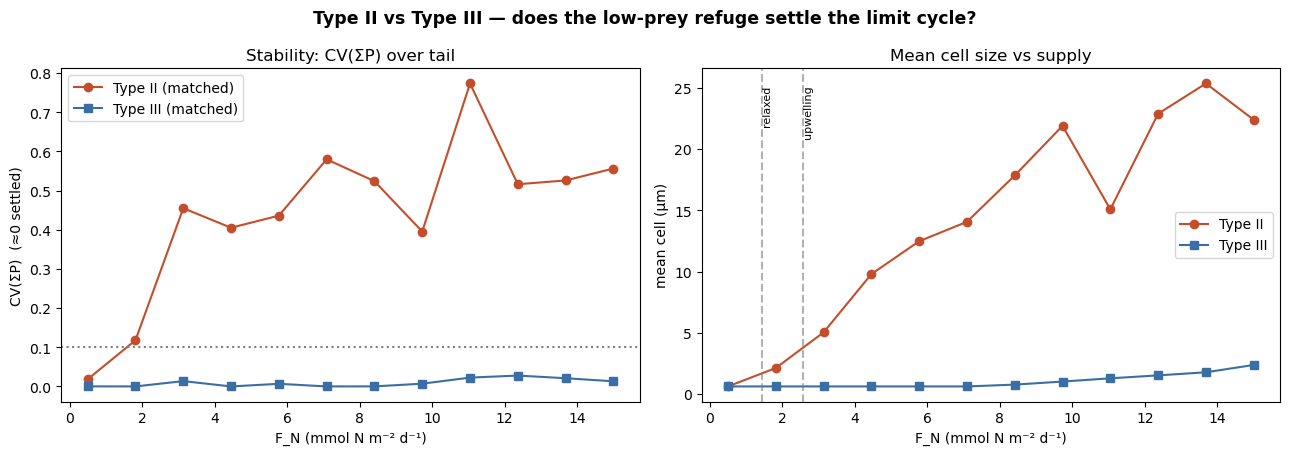

 F_N    CV_II   CV_III   mc_II   mc_III
 0.50   0.018   0.000    0.63    0.63
 1.82   0.118   0.000    2.13    0.63
 3.14   0.455   0.014    5.04    0.63
 4.45   0.405   0.000    9.79    0.63
 5.77   0.436   0.007   12.47    0.63
 7.09   0.580   0.000   14.05    0.63
 8.41   0.524   0.000   17.84    0.78
 9.73   0.395   0.007   21.88    1.03
11.05   0.773   0.023   15.07    1.29
12.36   0.516   0.028   22.87    1.53
13.68   0.526   0.021   25.34    1.78
15.00   0.556   0.013   22.38    2.38


In [17]:
# ── Fig 4 (cherry) — Stability: Type II vs Type III across the supply range ───
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_baseline_setups as cbs; importlib.reload(cbs)
import run_baseline_diagnostic as rbd

TAIL = 1500; fn_values = np.linspace(0.5, 15.0, 12)
def scan(model, setup):
    cv, mc = [], []
    for fn in fn_values:
        st = rbd.extract_state(rbd.run_setup(model, setup,
                 input_vars_override={'Supply': {'FN': float(fn)}}))
        m = rbd.compute_metrics(st, cbs.phyto_esd, cbs.zoo_esd, tail_len=TAIL)
        s = st['P'].sum(axis=0)[-TAIL:]
        cv.append(s.std()/max(s.mean(),1e-12)); mc.append(10**m['centroid'])
    return np.array(cv), np.array(mc)
cvII, mcII = scan(cbs.model_baseline,    cbs.model_setup_baseline)
cvIII, mcIII = scan(cbs.model_baseline_t3, cbs.model_setup_baseline_t3)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].plot(fn_values, cvII, 'o-', label='Type II (matched)', color='#c44e2c')
ax[0].plot(fn_values, cvIII, 's-', label='Type III (matched)', color='#3a6ea5')
ax[0].axhline(0.1, ls=':', c='grey'); ax[0].set(title='Stability: CV(ΣP) over tail',
             xlabel='F_N (mmol N m⁻² d⁻¹)', ylabel='CV(ΣP)  (≈0 settled)')
ax[1].plot(fn_values, mcII, 'o-', label='Type II', color='#c44e2c')
ax[1].plot(fn_values, mcIII, 's-', label='Type III', color='#3a6ea5')
for r in forc:
    ax[1].axvline(forc[r]['FN'], ls='--', c='grey', alpha=0.6)
    ax[1].annotate(r, (forc[r]['FN'], ax[1].get_ylim()[1]*0.95), fontsize=8, rotation=90, va='top')
ax[1].set(title='Mean cell size vs supply', xlabel='F_N (mmol N m⁻² d⁻¹)', ylabel='mean cell (µm)')
for a in ax: a.legend()
fig.suptitle('Type II vs Type III — does the low-prey refuge settle the limit cycle?',
             fontsize=12.5, weight='bold')
plt.tight_layout(); plt.show()
print(" F_N    CV_II   CV_III   mc_II   mc_III")
for i, fn in enumerate(fn_values):
    print(f"{fn:5.2f}  {cvII[i]:6.3f}  {cvIII[i]:6.3f}  {mcII[i]:6.2f}  {mcIII[i]:6.2f}")

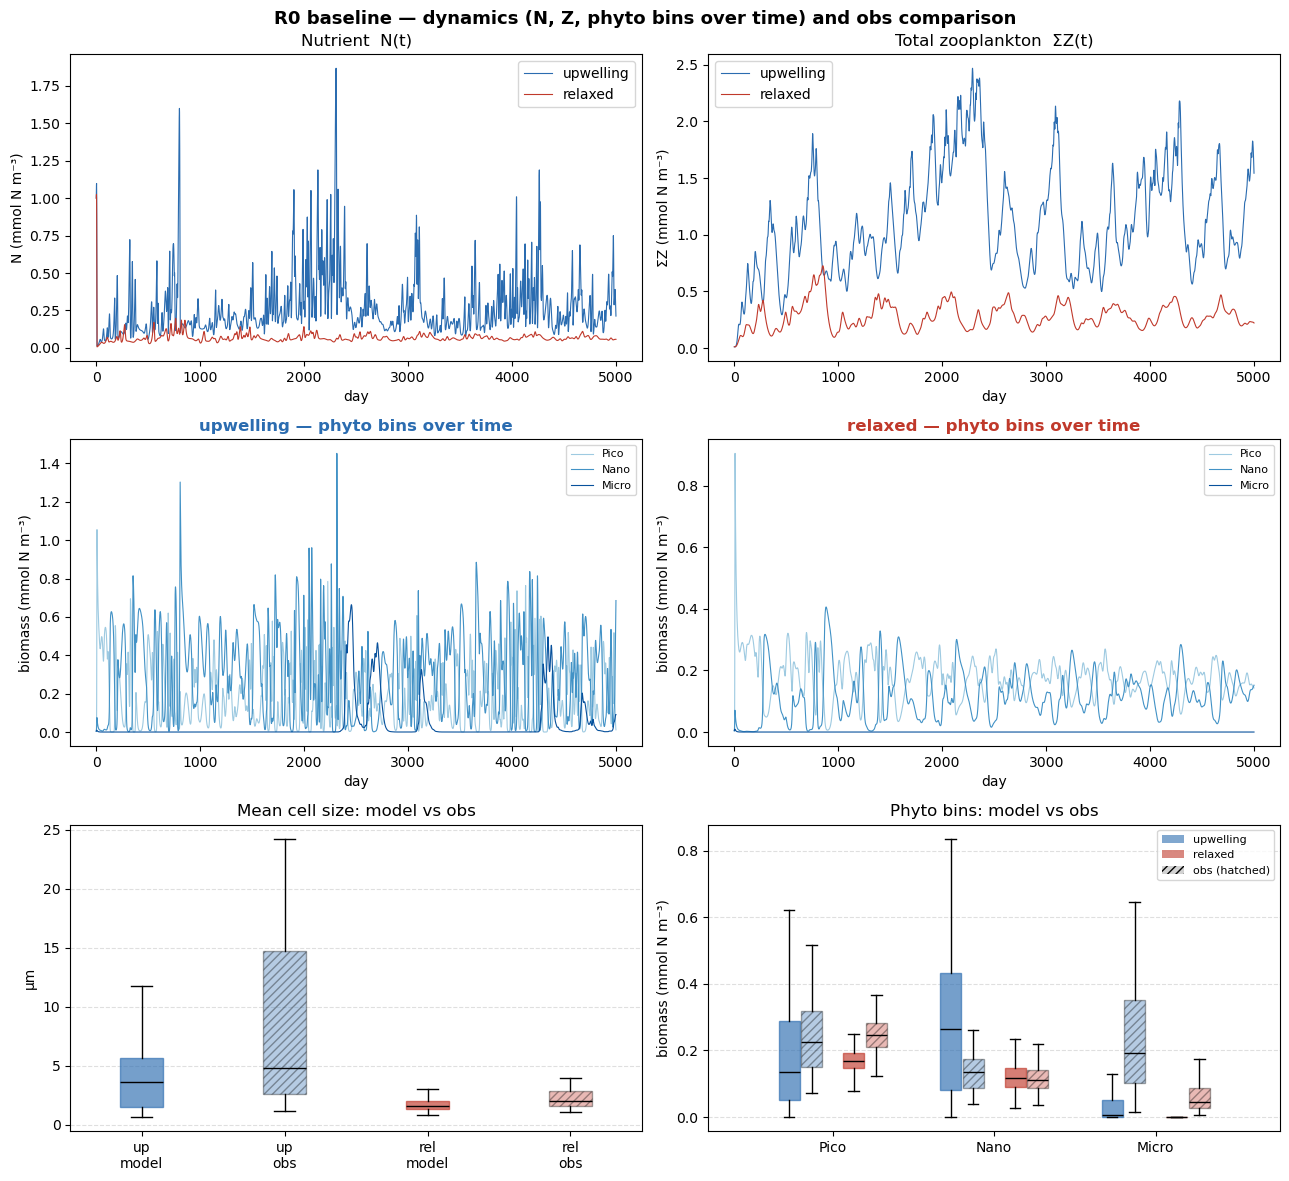

upwelling  mean cell — model 3.66 µm / obs 4.84 µm
relaxed    mean cell — model 1.62 µm / obs 2.01 µm


In [22]:
# ── Model dynamics + obs comparison (R0, Type II, no fish) ────────────────────
import importlib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cariaco_obs as co, run_baseline_diagnostic as rbd
import cariaco_baseline_setups as cbs; importlib.reload(cbs)

TAIL = 1000; regimes = ['upwelling', 'relaxed']
REG_COL = {'upwelling': '#2b6cb0', 'relaxed': '#c0392b'}
PHYTO_C = {'Pico': '#9ecae1', 'Nano': '#4292c6', 'Micro': '#08519c'}
LOG_GEO = np.log10([0.63, 6.3, 63.0]); binlab = list(PHYTO_C)
pe = cbs.phyto_esd
p_masks = [pe < 2.0, (pe >= 2.0) & (pe < 20.0), pe >= 20.0]

df = pd.read_csv(co.DEFAULT_CSV_PATH)
rc = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
phyto_cols = ['pico_mmolN', 'nano_mmolN', 'micro_mmolN']

def obs_pack(r):
    sub = df[df[rc] == r].dropna(subset=phyto_cols); P = sub[phyto_cols].values
    cent = (P / P.sum(1, keepdims=True)) @ LOG_GEO
    return dict(fn=sub['FN_mmolN_m2_d'].median(), de=sub['depth_cutoff'].median(),
                mcs=10**cent, bins=[P[:, k] for k in range(3)])

def model_run(r, fn, de):
    st = rbd.extract_state(rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
            input_vars_override={'Supply': {'FN': float(fn), 'de': float(de)},
                                 'PhytoSinking': {'w_over_de': float(cbs.W_SINK/de)}}))
    pbin_t = np.vstack([st['P'][m, :].sum(0) for m in p_masks])     # (3, ntime)
    pt = pbin_t[:, -TAIL:]; cent = (pt / pt.sum(0, keepdims=True)).T @ LOG_GEO
    return dict(N_t=st['N'], sumZ_t=st['Z'].sum(0), pbin_t=pbin_t,
                mcs=10**cent, bins=[pt[k, :] for k in range(3)])

obs = {r: obs_pack(r) for r in regimes}
mod = {r: model_run(r, obs[r]['fn'], obs[r]['de']) for r in regimes}
t = np.arange(mod['upwelling']['N_t'].size)

def box(ax, pos, data, color, isobs=False, width=0.3):
    data = np.asarray(data, float); data = data[np.isfinite(data)]
    if data.size == 0:
        ax.text(pos, 0.5, 'no obs', transform=ax.get_xaxis_transform(), ha='center', fontsize=7, color='grey'); return
    bp = ax.boxplot([data], positions=[pos], widths=width, patch_artist=True, showfliers=False)
    b = bp['boxes'][0]; b.set_facecolor(color); b.set_edgecolor('k' if isobs else color)
    b.set_alpha(0.35 if isobs else 0.65)
    if isobs: b.set_hatch('////')
    bp['medians'][0].set_color('k')

fig, ax = plt.subplots(3, 2, figsize=(13, 12))
# Row 0 — N(t), ΣZ(t)
for r in regimes:
    ax[0, 0].plot(t, mod[r]['N_t'], color=REG_COL[r], lw=0.8, label=r)
    ax[0, 1].plot(t, mod[r]['sumZ_t'], color=REG_COL[r], lw=0.8, label=r)
ax[0, 0].set(title='Nutrient  N(t)', xlabel='day', ylabel='N (mmol N m⁻³)'); ax[0, 0].legend()
ax[0, 1].set(title='Total zooplankton  ΣZ(t)', xlabel='day', ylabel='ΣZ (mmol N m⁻³)'); ax[0, 1].legend()
# Row 1 — phyto bins over time, one panel per regime
for ci, r in enumerate(regimes):
    for k, lab in enumerate(binlab):
        ax[1, ci].plot(t, mod[r]['pbin_t'][k], color=PHYTO_C[lab], lw=0.8, label=lab)
    ax[1, ci].set(xlabel='day', ylabel='biomass (mmol N m⁻³)')
    ax[1, ci].set_title(f'{r} — phyto bins over time', color=REG_COL[r], weight='bold')
    ax[1, ci].legend(fontsize=8)
# Row 2 — comparisons (model tail dist vs obs monthly)
a = ax[2, 0]
for x, (r, ob) in zip([0, 1, 2, 3], [('upwelling', False), ('upwelling', True), ('relaxed', False), ('relaxed', True)]):
    box(a, x, (obs[r]['mcs'] if ob else mod[r]['mcs']), REG_COL[r], isobs=ob)
a.set_xticks(range(4)); a.set_xticklabels(['up\nmodel', 'up\nobs', 'rel\nmodel', 'rel\nobs'])
a.set(title='Mean cell size: model vs obs', ylabel='µm'); a.grid(axis='y', ls='--', alpha=0.4)
a = ax[2, 1]
off = {'upwelling': -0.2, 'relaxed': 0.2}
for k in range(3):
    for r in regimes:
        box(a, k + off[r] - 0.07, mod[r]['bins'][k], REG_COL[r], width=0.13)
        box(a, k + off[r] + 0.07, obs[r]['bins'][k], REG_COL[r], isobs=True, width=0.13)
a.set_xticks(range(3)); a.set_xticklabels(binlab)
a.set(title='Phyto bins: model vs obs', ylabel='biomass (mmol N m⁻³)'); a.grid(axis='y', ls='--', alpha=0.4)
a.legend(handles=[Patch(facecolor=REG_COL['upwelling'], alpha=.6, label='upwelling'),
                  Patch(facecolor=REG_COL['relaxed'], alpha=.6, label='relaxed'),
                  Patch(facecolor='0.5', alpha=.35, hatch='////', label='obs (hatched)')], fontsize=8)
fig.suptitle('R0 baseline — dynamics (N, Z, phyto bins over time) and obs comparison', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

for r in regimes:
    print(f"{r:10s} mean cell — model {np.median(mod[r]['mcs']):.2f} µm / obs {np.median(obs[r]['mcs']):.2f} µm")

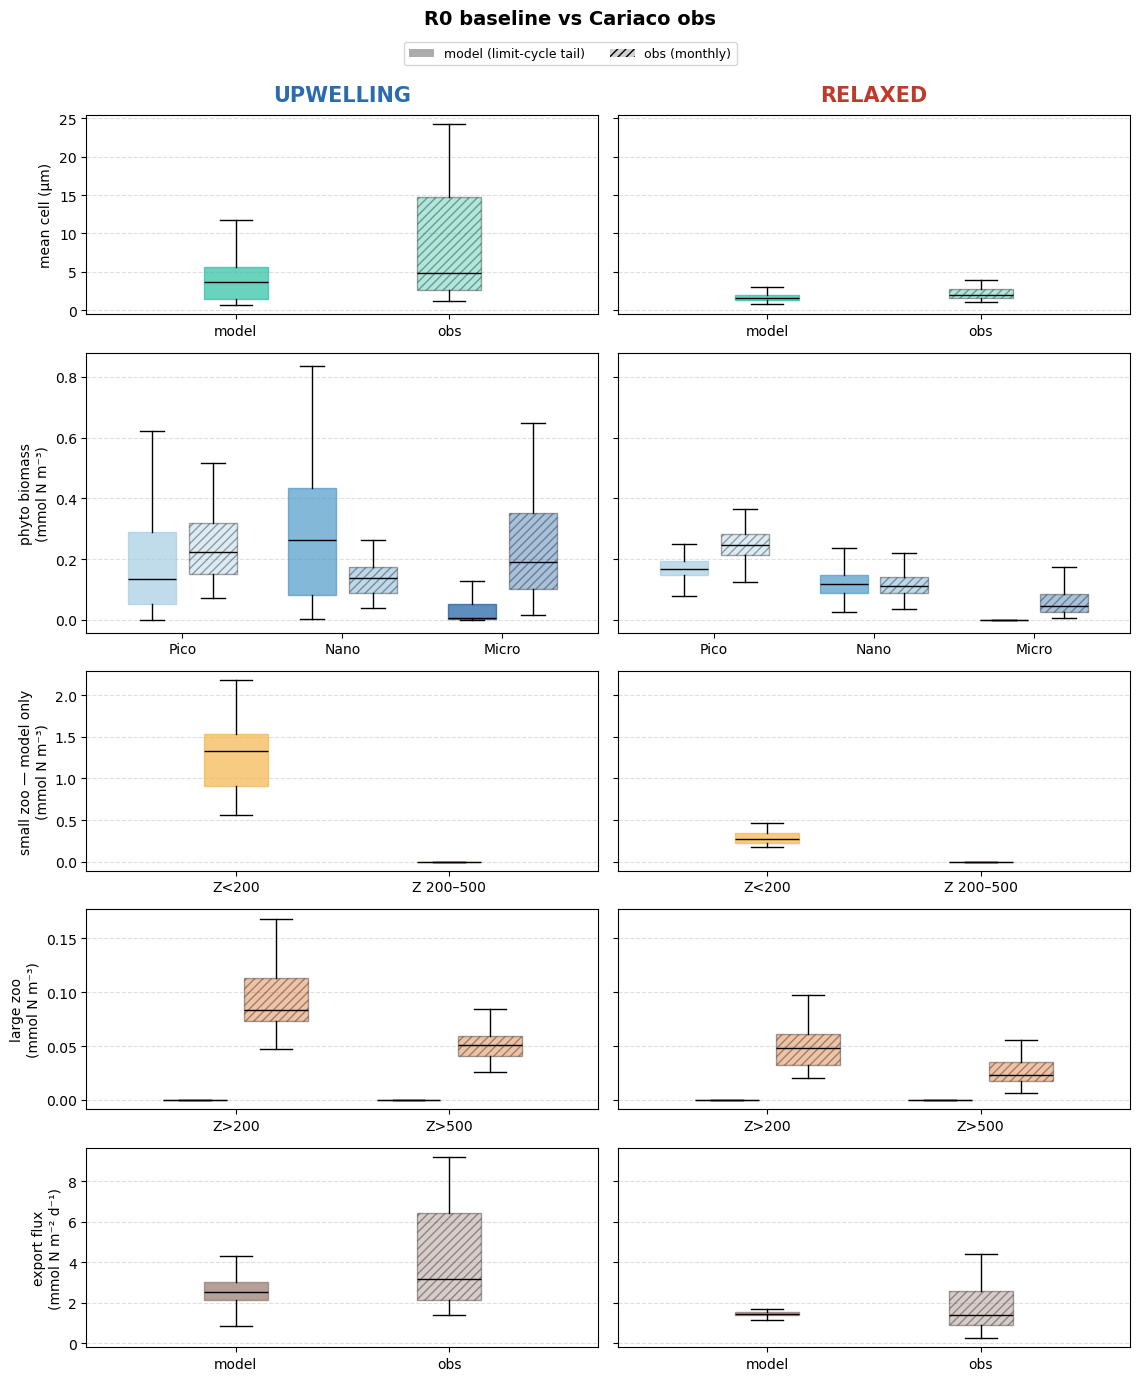

upwelling  mean cell — model 3.66 µm / obs 4.84 µm
relaxed    mean cell — model 1.62 µm / obs 2.01 µm


In [19]:
# ── Fig 3 (v3) — Model (tail dist) vs obs (monthly), regimes side by side ─────
import importlib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cariaco_obs as co, run_baseline_diagnostic as rbd
import cariaco_baseline_setups as cbs; importlib.reload(cbs)

TAIL = 1000; regimes = ['upwelling', 'relaxed']
REG_COL = {'upwelling': '#2b6cb0', 'relaxed': '#c0392b'}
MEAN_C, ZS, ZL, EXP = '#1abc9c', '#f5b041', '#d35400', '#8d6e63'
PHYTO_C = {'Pico': '#9ecae1', 'Nano': '#4292c6', 'Micro': '#08519c'}
LOG_GEO = np.log10([0.63, 6.3, 63.0])
pe, ze = cbs.phyto_esd, cbs.zoo_esd
p_masks = [pe < 2.0, (pe >= 2.0) & (pe < 20.0), pe >= 20.0]
zmask = dict(lt200=ze < 200, b200_500=(ze >= 200) & (ze < 500), gt200=ze >= 200, gt500=ze >= 500)

df = pd.read_csv(co.DEFAULT_CSV_PATH)
rc = 'regime_adjusted' if 'regime_adjusted' in df.columns else 'upwelling'
phyto_cols = ['pico_mmolN', 'nano_mmolN', 'micro_mmolN']

def obs_pack(r):
    sub = df[df[rc] == r].dropna(subset=phyto_cols); P = sub[phyto_cols].values
    cent = (P / P.sum(1, keepdims=True)) @ LOG_GEO
    return dict(fn=sub['FN_mmolN_m2_d'].median(), de=sub['depth_cutoff'].median(),
                mcs=10**cent, bins=[P[:, k] for k in range(3)],
                z200=sub['zoo_gt200_mmolN'].dropna().values, z500=sub['zoo_gt500_mmolN'].dropna().values,
                export=sub['export_flux_corrected_mmolN'].dropna().values)

def model_pack(r, fn, de):
    st = rbd.extract_state(rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
            input_vars_override={'Supply': {'FN': float(fn), 'de': float(de)},
                                 'PhytoSinking': {'w_over_de': float(cbs.W_SINK/de)}}))
    Pt, Zt = st['P'][:, -TAIL:], st['Z'][:, -TAIL:]
    pbin = np.vstack([Pt[m, :].sum(0) for m in p_masks])
    cent = (pbin / pbin.sum(0, keepdims=True)).T @ LOG_GEO
    return dict(mcs=10**cent, bins=[pbin[k, :] for k in range(3)],
                export=cbs.W_SINK * Pt.sum(0), **{k: Zt[mk, :].sum(0) for k, mk in zmask.items()})

obs = {r: obs_pack(r) for r in regimes}
mod = {r: model_pack(r, obs[r]['fn'], obs[r]['de']) for r in regimes}

def box(ax, pos, data, color, obs=False, width=0.30):
    data = np.asarray(data, float); data = data[np.isfinite(data)]
    if data.size == 0:
        ax.text(pos, 0.5, 'no\nobs', transform=ax.get_xaxis_transform(),
                ha='center', va='center', fontsize=7, color='grey'); return
    bp = ax.boxplot([data], positions=[pos], widths=width, patch_artist=True, showfliers=False)
    b = bp['boxes'][0]; b.set_facecolor(color); b.set_edgecolor('k' if obs else color)
    b.set_alpha(0.35 if obs else 0.65)
    if obs: b.set_hatch('////')
    bp['medians'][0].set_color('k')

fig, ax = plt.subplots(5, 2, figsize=(11.5, 13.5), sharey='row',
                       gridspec_kw={'height_ratios': [1, 1.4, 1, 1, 1]})
for ci, r in enumerate(regimes):
    o, m = obs[r], mod[r]
    a = ax[0, ci]; box(a, 0, m['mcs'], MEAN_C); box(a, 1, o['mcs'], MEAN_C, obs=True)
    a.set_xticks([0, 1]); a.set_xticklabels(['model', 'obs']); a.set_xlim(-0.7, 1.7)
    a.set_title(r.upper(), color=REG_COL[r], fontsize=15, weight='bold', pad=10)
    a = ax[1, ci]
    for k, (lab, col) in enumerate(PHYTO_C.items()):
        box(a, k-0.19, m['bins'][k], col); box(a, k+0.19, o['bins'][k], col, obs=True)
    a.set_xticks(range(3)); a.set_xticklabels(list(PHYTO_C)); a.set_xlim(-0.6, 2.6)
    a = ax[2, ci]; box(a, 0, m['lt200'], ZS); box(a, 1, m['b200_500'], ZS)
    a.set_xticks([0, 1]); a.set_xticklabels(['Z<200', 'Z 200–500']); a.set_xlim(-0.7, 1.7)
    a = ax[3, ci]
    box(a, -0.19, m['gt200'], ZL); box(a, 0.19, o['z200'], ZL, obs=True)
    box(a, 1-0.19, m['gt500'], ZL); box(a, 1+0.19, o['z500'], ZL, obs=True)
    a.set_xticks([0, 1]); a.set_xticklabels(['Z>200', 'Z>500']); a.set_xlim(-0.7, 1.7)
    a = ax[4, ci]; box(a, 0, m['export'], EXP); box(a, 1, o['export'], EXP, obs=True)
    a.set_xticks([0, 1]); a.set_xticklabels(['model', 'obs']); a.set_xlim(-0.7, 1.7)
    for rr in range(5): ax[rr, ci].grid(axis='y', ls='--', alpha=0.4)

ax[0,0].set_ylabel('mean cell (µm)'); ax[1,0].set_ylabel('phyto biomass\n(mmol N m⁻³)')
ax[2,0].set_ylabel('small zoo — model only\n(mmol N m⁻³)'); ax[3,0].set_ylabel('large zoo\n(mmol N m⁻³)')
ax[4,0].set_ylabel('export flux\n(mmol N m⁻² d⁻¹)')
fig.legend(handles=[Patch(facecolor='0.5', alpha=.65, label='model (limit-cycle tail)'),
                    Patch(facecolor='0.5', alpha=.35, hatch='////', label='obs (monthly)')],
           loc='upper center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.0))
fig.suptitle('R0 baseline vs Cariaco obs', fontsize=14, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

for r in regimes:
    print(f"{r:10s} mean cell — model {np.median(mod[r]['mcs']):.2f} µm / obs {np.median(obs[r]['mcs']):.2f} µm")

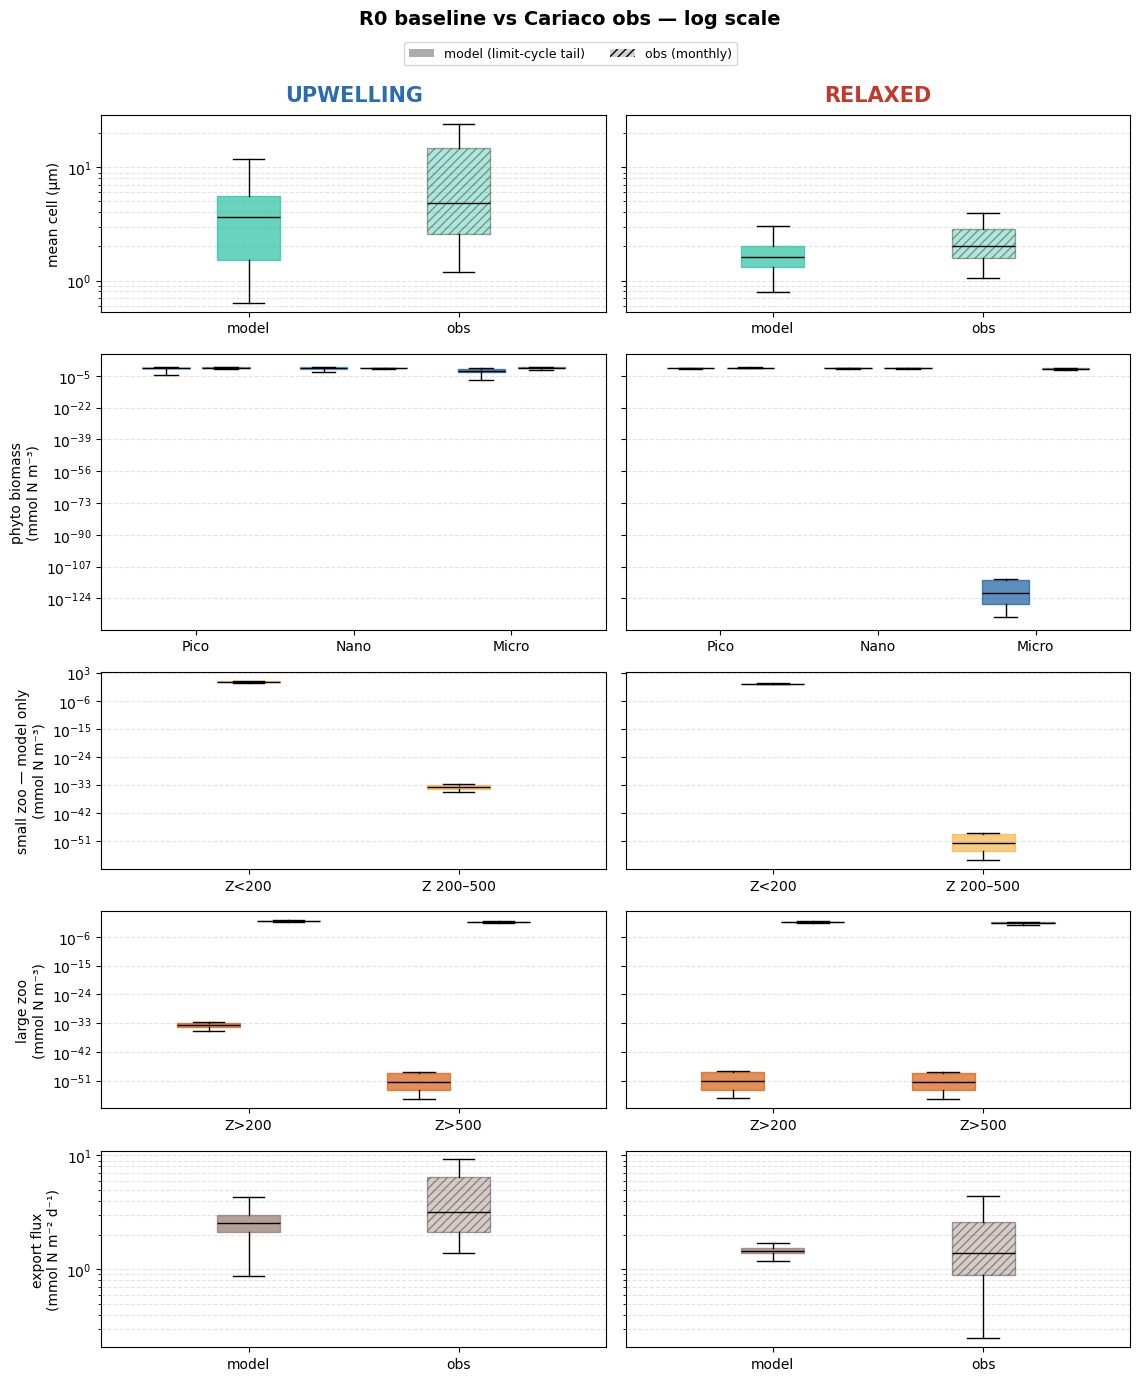

In [20]:
# ── Fig 3 (v3-log) — same comparison, all y-axes log ─────────────────────────
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
REG_COL = {'upwelling': '#2b6cb0', 'relaxed': '#c0392b'}
MEAN_C, ZS, ZL, EXP = '#1abc9c', '#f5b041', '#d35400', '#8d6e63'
PHYTO_C = {'Pico': '#9ecae1', 'Nano': '#4292c6', 'Micro': '#08519c'}

def boxlog(ax, pos, data, color, obs=False, width=0.30):
    data = np.asarray(data, float); data = data[np.isfinite(data) & (data > 0)]   # >0 for log
    if data.size == 0:
        ax.text(pos, 0.5, 'no\nobs', transform=ax.get_xaxis_transform(),
                ha='center', va='center', fontsize=7, color='grey'); return
    bp = ax.boxplot([data], positions=[pos], widths=width, patch_artist=True, showfliers=False)
    b = bp['boxes'][0]; b.set_facecolor(color); b.set_edgecolor('k' if obs else color)
    b.set_alpha(0.35 if obs else 0.65)
    if obs: b.set_hatch('////')
    bp['medians'][0].set_color('k')

fig, ax = plt.subplots(5, 2, figsize=(11.5, 13.5), sharey='row',
                       gridspec_kw={'height_ratios': [1, 1.4, 1, 1, 1]})
for ci, r in enumerate(regimes):
    o, m = obs[r], mod[r]
    a = ax[0, ci]; boxlog(a, 0, m['mcs'], MEAN_C); boxlog(a, 1, o['mcs'], MEAN_C, obs=True)
    a.set_xticks([0, 1]); a.set_xticklabels(['model', 'obs']); a.set_xlim(-0.7, 1.7)
    a.set_title(r.upper(), color=REG_COL[r], fontsize=15, weight='bold', pad=10)
    a = ax[1, ci]
    for k, (lab, col) in enumerate(PHYTO_C.items()):
        boxlog(a, k-0.19, m['bins'][k], col); boxlog(a, k+0.19, o['bins'][k], col, obs=True)
    a.set_xticks(range(3)); a.set_xticklabels(list(PHYTO_C)); a.set_xlim(-0.6, 2.6)
    a = ax[2, ci]; boxlog(a, 0, m['lt200'], ZS); boxlog(a, 1, m['b200_500'], ZS)
    a.set_xticks([0, 1]); a.set_xticklabels(['Z<200', 'Z 200–500']); a.set_xlim(-0.7, 1.7)
    a = ax[3, ci]
    boxlog(a, -0.19, m['gt200'], ZL); boxlog(a, 0.19, o['z200'], ZL, obs=True)
    boxlog(a, 1-0.19, m['gt500'], ZL); boxlog(a, 1+0.19, o['z500'], ZL, obs=True)
    a.set_xticks([0, 1]); a.set_xticklabels(['Z>200', 'Z>500']); a.set_xlim(-0.7, 1.7)
    a = ax[4, ci]; boxlog(a, 0, m['export'], EXP); boxlog(a, 1, o['export'], EXP, obs=True)
    a.set_xticks([0, 1]); a.set_xticklabels(['model', 'obs']); a.set_xlim(-0.7, 1.7)
    for rr in range(5):
        ax[rr, ci].set_yscale('log'); ax[rr, ci].grid(axis='y', which='both', ls='--', alpha=0.35)

ax[0,0].set_ylabel('mean cell (µm)'); ax[1,0].set_ylabel('phyto biomass\n(mmol N m⁻³)')
ax[2,0].set_ylabel('small zoo — model only\n(mmol N m⁻³)'); ax[3,0].set_ylabel('large zoo\n(mmol N m⁻³)')
ax[4,0].set_ylabel('export flux\n(mmol N m⁻² d⁻¹)')
fig.legend(handles=[Patch(facecolor='0.5', alpha=.65, label='model (limit-cycle tail)'),
                    Patch(facecolor='0.5', alpha=.35, hatch='////', label='obs (monthly)')],
           loc='upper center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.0))
fig.suptitle('R0 baseline vs Cariaco obs — log scale', fontsize=14, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

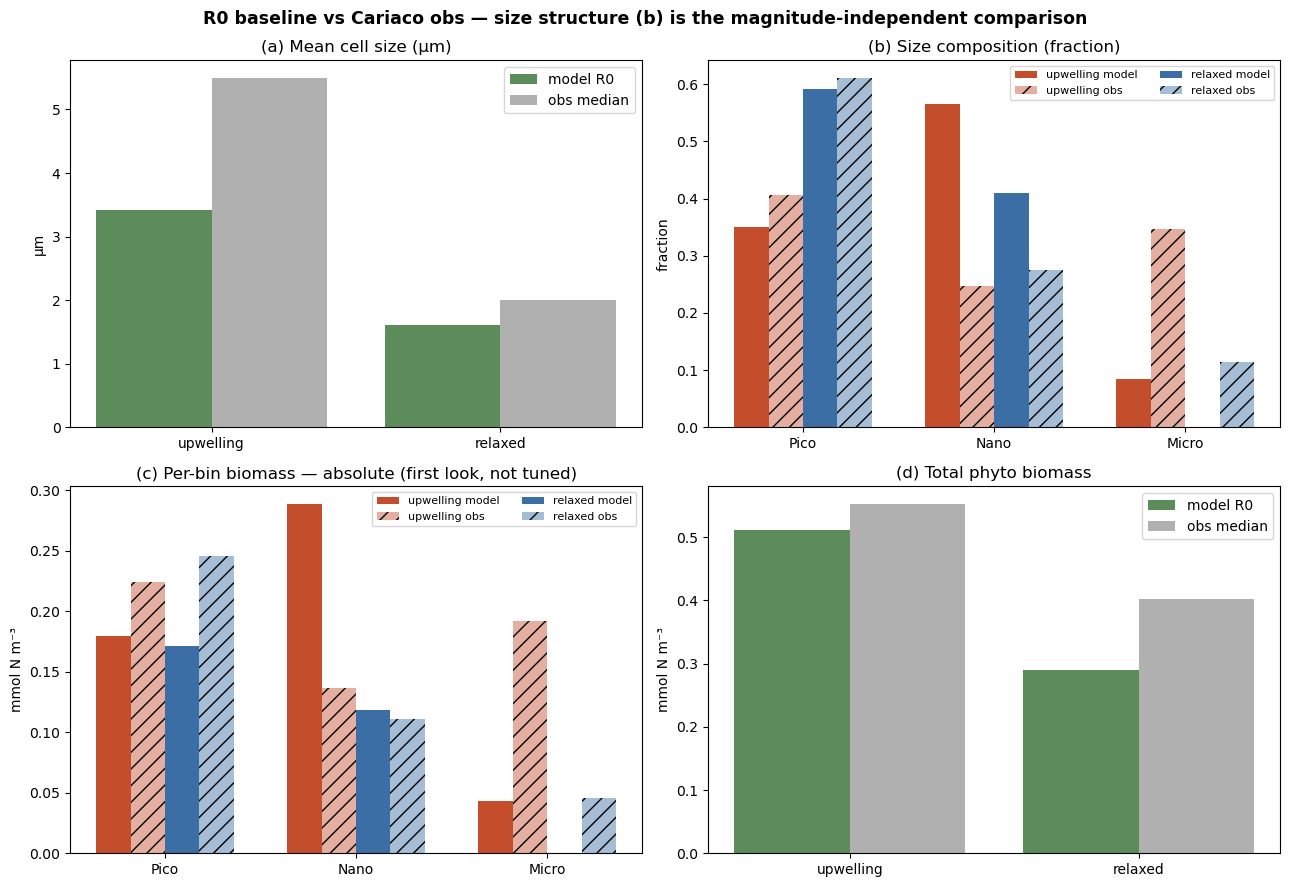

In [16]:
# ── Fig 3 — Model (R0, Type II) vs obs: size structure + biomass ──────────────
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_obs as co, run_baseline_diagnostic as rbd
import cariaco_baseline_setups as cbs; importlib.reload(cbs)
from parscan_utils import compute_phyto_spectrum_metrics

pbdef = [b for b in co.TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']
regimes = ['upwelling', 'relaxed']; TAIL = 1000; COL = {'upwelling': '#c44e2c', 'relaxed': '#3a6ea5'}
forc, mod_bins, obs_bins, mcs = {}, {}, {}, {}
for r in regimes:
    ov, labels, _, _, forcing = co.load_cariaco_targets(regime=r, months='hplc', agg='median')
    fn, de = forcing['Inflow__FN'], forcing['Inflow__de']
    obs_bins[r] = np.array([ov[labels.index(b['label'])] for b in pbdef])
    obs_cent = compute_phyto_spectrum_metrics(obs_bins[r], pbdef)['centroid']
    forc[r] = dict(FN=fn, de=de, obs_mcs=10**obs_cent)
    st = rbd.extract_state(rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
            input_vars_override={'Supply': {'FN': float(fn), 'de': float(de)},
                                 'PhytoSinking': {'w_over_de': float(cbs.W_SINK/de)}}))
    m = rbd.compute_metrics(st, cbs.phyto_esd, cbs.zoo_esd, tail_len=TAIL)
    mod_bins[r] = np.asarray(m['P_bins'], float); mcs[r] = 10**m['centroid']

binlab = ['Pico', 'Nano', 'Micro']; x = np.arange(3); xr = np.arange(len(regimes)); w = 0.18
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax[0,0].bar(xr-0.2, [mcs[r] for r in regimes], 0.4, label='model R0', color='#5b8c5a')
ax[0,0].bar(xr+0.2, [forc[r]['obs_mcs'] for r in regimes], 0.4, label='obs median', color='#b0b0b0')
ax[0,0].set(title='(a) Mean cell size (µm)', ylabel='µm', xticks=xr); ax[0,0].set_xticklabels(regimes); ax[0,0].legend()
for i, r in enumerate(regimes):
    mf, of = mod_bins[r]/mod_bins[r].sum(), obs_bins[r]/obs_bins[r].sum()
    ax[0,1].bar(x + (2*i-1)*w - w/2, mf, w, color=COL[r], label=f'{r} model')
    ax[0,1].bar(x + (2*i-1)*w + w/2, of, w, color=COL[r], alpha=0.45, hatch='//', label=f'{r} obs')
ax[0,1].set(title='(b) Size composition (fraction)', ylabel='fraction', xticks=x); ax[0,1].set_xticklabels(binlab); ax[0,1].legend(fontsize=8, ncol=2)
for i, r in enumerate(regimes):
    ax[1,0].bar(x + (2*i-1)*w - w/2, mod_bins[r], w, color=COL[r], label=f'{r} model')
    ax[1,0].bar(x + (2*i-1)*w + w/2, obs_bins[r], w, color=COL[r], alpha=0.45, hatch='//', label=f'{r} obs')
ax[1,0].set(title='(c) Per-bin biomass — absolute (first look, not tuned)', ylabel='mmol N m⁻³', xticks=x); ax[1,0].set_xticklabels(binlab); ax[1,0].legend(fontsize=8, ncol=2)
ax[1,1].bar(xr-0.2, [mod_bins[r].sum() for r in regimes], 0.4, label='model R0', color='#5b8c5a')
ax[1,1].bar(xr+0.2, [obs_bins[r].sum() for r in regimes], 0.4, label='obs median', color='#b0b0b0')
ax[1,1].set(title='(d) Total phyto biomass', ylabel='mmol N m⁻³', xticks=xr); ax[1,1].set_xticklabels(regimes); ax[1,1].legend()
fig.suptitle('R0 baseline vs Cariaco obs — size structure (b) is the magnitude-independent comparison',
             fontsize=12.5, weight='bold')
plt.tight_layout(); plt.show()